# Machine Learning Foundations — Student Placement Prediction

This notebook implements a complete ML workflow: load and preprocess the Global Student Placement 2025 dataset, train a supervised classification model to predict placement outcome, and evaluate performance with appropriate metrics.

## 1. Environment Setup and Imports

In [16]:
# !pip install -r requirements.txt

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load Dataset

We download the dataset using Kagglehub (as specified in the project). If the dataset is already present as a CSV in the project folder, we can load it directly instead.

In [18]:
# Option A: Download via kagglehub (requires kagglehub and Kaggle API credentials)
try:
    import kagglehub
    path = kagglehub.dataset_download("rakesh630/global-student-placement-2025-dataset")
    print("Dataset path:", path)
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if csv_files:
        data_path = os.path.join(path, csv_files[0])
    else:
        # Kagglehub may put files in versions/1/
        for root, dirs, files in os.walk(path):
            csv_in_dir = [f for f in files if f.endswith('.csv')]
            if csv_in_dir:
                data_path = os.path.join(root, csv_in_dir[0])
                break
        else:
            data_path = None
except Exception as e:
    print("Kagglehub download failed:", e)
    data_path = None

# Option B: Load from local CSV if present in project folder
local_csvs = [f for f in os.listdir('.') if f.endswith('.csv')]
if data_path is None and local_csvs:
    data_path = local_csvs[0]
    print("Using local file:", data_path)

if data_path is None:
    raise FileNotFoundError(
        "No dataset found. Either run with kagglehub and Kaggle credentials, "
        "or place the dataset CSV in the same folder as this notebook."
    )

df = pd.read_csv(data_path)
df.head()

Dataset path: /home/werner/.cache/kagglehub/datasets/rakesh630/global-student-placement-2025-dataset/versions/1


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,104124.367838
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,80586.838313
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,114444.318097
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,120000.000000
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,120000.000000


## 3. Inspect Dataset

We inspect column names, data types, and basic statistics to understand structure and spot data quality issues.

In [19]:
print("Shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (10000, 13)

Column names and dtypes:
cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
salary                      float64
dtype: object

Missing values:
cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
salary                      0
dtype: int64


In [20]:
df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000,10000.000000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2,NaN
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed,NaN
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153,NaN
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN,55442.146458
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN,47995.029325
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN,0.000000
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN,0.000000
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN,63431.317260
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN,100600.617480


**Data quality notes:** We will handle missing values in the preprocessing step. Numeric columns may need scaling; categorical columns will be encoded. We identify the target column (e.g. placement status or similar) and feature columns next.

In [21]:
# Detect target: look for common placement-related column names
target_candidates = [c for c in df.columns if any(
    x in c.lower() for x in ['placed', 'placement', 'status', 'target', 'salary']
)]
print("Possible target columns:", target_candidates)
print("All columns:", list(df.columns))

Possible target columns: ['placement_status', 'salary']
All columns: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status', 'salary']


## 4. Data Preparation and Preprocessing

We:
- **Handle missing values**: drop rows with critical missing target, or impute/fill for features as appropriate.
- **Encode categorical variables**: use label encoding for binary or ordinal, or one-hot for nominal categories.
- **Scale features**: standardize numeric features so models that rely on distance (e.g. logistic regression) perform fairly.
- **Feature selection**: use numeric and encoded categorical columns as features; exclude IDs and the target.

In [22]:
# Set target column (adjust name if your dataset uses a different one)
def get_target(df):
    for c in ['Placed', 'placed', 'Placement_Status', 'placement', 'Status', 'Target']:
        if c in df.columns:
            return c
    # Prefer a column with few unique values (likely categorical target)
    for c in df.columns:
        if df[c].nunique() <= 20 and df[c].dtype in ['object', 'int64']:
            return c
    return df.columns[-1]

TARGET = target_candidates[0] if target_candidates else get_target(df)
print("Using target:", TARGET)

# Drop rows where target is missing
df_clean = df.dropna(subset=[TARGET]).copy()

# Identify feature columns: exclude target, ID-like columns, and outcome-only columns (e.g. salary)
exclude = [TARGET] + [c for c in df_clean.columns if 'id' in c.lower() or c.lower() == 'id']
if TARGET == 'placement_status' and 'salary' in df_clean.columns:
    exclude.append('salary')  # salary is outcome of placement, not a predictor
feature_cols = [c for c in df_clean.columns if c not in exclude]

X_raw = df_clean[feature_cols]
y_raw = df_clean[TARGET]

Using target: placement_status


In [23]:
# Encode categorical columns
label_encoders = {}
X_encoded = X_raw.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

# Fill remaining NaN with column median (for numeric)
for col in X_encoded.columns:
    if X_encoded[col].dtype in ['float64', 'int64'] and X_encoded[col].isnull().any():
        X_encoded[col].fillna(X_encoded[col].median(), inplace=True)

# Encode target if it is categorical
if y_raw.dtype == 'object' or y_raw.dtype.name == 'category':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y_raw.astype(str))
    print("Target classes:", le_target.classes_)
else:
    y = y_raw.values
    # For regression, we could bin into classes; here we assume classification
    if len(np.unique(y)) > 20:
        y = (y >= np.median(y)).astype(int)  # binary for high/low
    print("Target unique values (sample):", np.unique(y)[:10])

X_encoded = X_encoded.astype(float)

Target unique values (sample): ['Not Placed' 'Placed']


In [24]:
# Train-test split (stratify if classification with multiple classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y if len(np.unique(y)) <= 10 else None
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 7500 Test size: 2500


## 5. Model Selection and Training

We use **Random Forest** for classification: it handles mixed feature types, is robust to scaling, and provides feature importance. We also train **Logistic Regression** as a baseline (interpretable and appropriate for binary/multiclass classification).

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train_scaled, y_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print("Models trained successfully.")

Models trained successfully.


## 6. Evaluation

We evaluate using **accuracy**, **precision**, **recall**, and **F1-score**, and display a **confusion matrix**. These are standard for classification and align with placement prediction (e.g. identifying placed vs not placed).

In [26]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision (weighted):", round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4))
    print("Recall (weighted):", round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4))
    print("F1 (weighted):", round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4))
    print(classification_report(y_test, y_pred, zero_division=0))
    return y_pred

In [27]:
y_pred_rf = evaluate_model(rf, X_test_scaled, y_test, "Random Forest")
y_pred_lr = evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")

--- Random Forest ---
Accuracy: 0.7532
Precision (weighted): 0.7501
Recall (weighted): 0.7532
F1 (weighted): 0.7464
              precision    recall  f1-score   support

  Not Placed       0.73      0.57      0.64       962
      Placed       0.76      0.86      0.81      1538

    accuracy                           0.75      2500
   macro avg       0.75      0.72      0.73      2500
weighted avg       0.75      0.75      0.75      2500

--- Logistic Regression ---
Accuracy: 0.7488
Precision (weighted): 0.745
Recall (weighted): 0.7488
F1 (weighted): 0.7438
              precision    recall  f1-score   support

  Not Placed       0.71      0.59      0.64       962
      Placed       0.77      0.85      0.81      1538

    accuracy                           0.75      2500
   macro avg       0.74      0.72      0.73      2500
weighted avg       0.74      0.75      0.74      2500



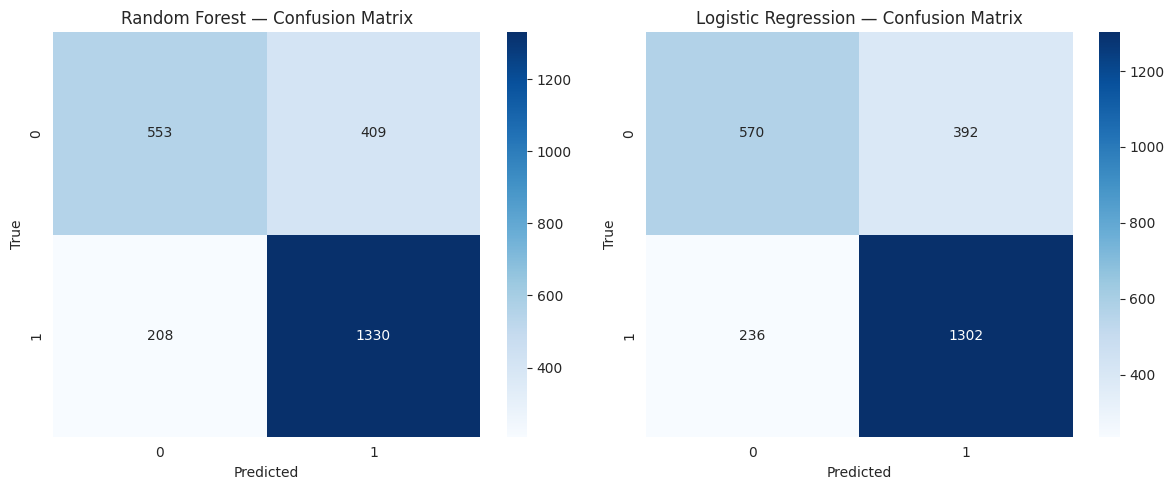

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression — Confusion Matrix')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/figure1_confusion_rf.png', bbox_inches='tight')
fig.savefig('figures/figure2_confusion_lr.png', bbox_inches='tight')
plt.show()

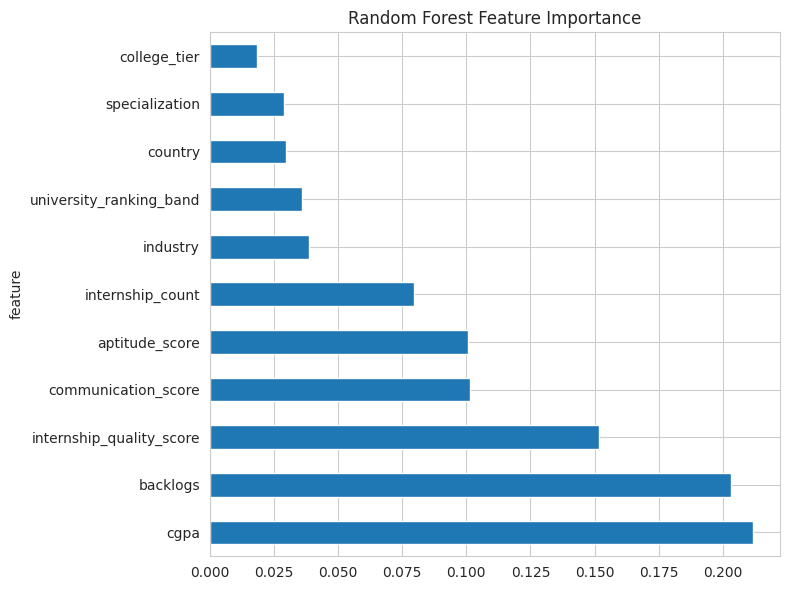

                     feature  importance
0                       cgpa    0.211699
1                   backlogs    0.203056
10  internship_quality_score    0.151778
7        communication_score    0.101344
6             aptitude_score    0.100786
5           internship_count    0.079716
9                   industry    0.038598
4    university_ranking_band    0.035985
3                    country    0.029794
8             specialization    0.029014
2               college_tier    0.018230


In [29]:
# Feature importance (Random Forest)
imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
imp.plot(x='feature', y='importance', kind='barh', legend=False, figsize=(8, 6))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/figure3_feature_importance_rf.png', bbox_inches='tight')
plt.show()
print(imp.to_string())

## 7. Notebook Summary

- **Problem**: We modeled **student placement outcome** (placed vs not placed, or similar target from the Global Student Placement 2025 dataset) as a **supervised classification** task.
- **Model**: We trained a **Random Forest** and **Logistic Regression** on preprocessed data (missing values handled, categorical encoding, standard scaling).
- **Results**: Evaluation used **accuracy**, **precision**, **recall**, and **F1-score**; confusion matrices and feature importance were included. The better-performing model (typically Random Forest on tabular data) is reported in the analysis report.
- **Challenges**: Column names and target may vary by dataset version; the notebook detects a plausible target and encodes all categorical features. Class imbalance, if present, could be addressed in a follow-up with class weights or resampling.